# Geometry of Truth Dataset — Exploratory Data Analysis

This notebook explores the Geometry of Truth dataset for use in the SAE-Faithful project. The goal is to inspect the dataset structure, understand the true/false statement labels, assess data quality, and prepare the dataset for later concept-detection and causal-faithfulness experiments.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/saprmarks/geometry-of-truth/main/datasets/cities.csv"

cities = pd.read_csv(url)

cities.head()

,statement,label,city,country,correct_country
0,The city of Krasnodar is in Russia.,1,Krasnodar,Russia,Russia
1,The city of Krasnodar is in South Africa.,0,Krasnodar,South Africa,Russia
2,The city of Lodz is in Poland.,1,Lodz,Poland,Poland
3,The city of Lodz is in the Dominican Republic.,0,Lodz,the Dominican Republic,Poland
4,The city of Maracay is in Venezuela.,1,Maracay,Venezuela,Venezuela


In [6]:
print("Shape:", cities.shape)

print("\nColumns:")
print(cities.columns.tolist())

print("\nData types:")
print(cities.dtypes)

print("\nMissing values:")
print(cities.isnull().sum())

print("\nLabel distribution:")
print(cities["label"].value_counts())

print("\nLabel proportions:")
print(cities["label"].value_counts(normalize=True))

Shape: (1496, 5)

Columns:
['statement', 'label', 'city', 'country', 'correct_country']

Data types:
statement          object
label               int64
city               object
country            object
correct_country    object
dtype: object

Missing values:
statement          0
label              0
city               0
country            0
correct_country    0
dtype: int64

Label distribution:
label
1    748
0    748
Name: count, dtype: int64

Label proportions:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [7]:
# Text length analysis
cities["char_length"] = cities["statement"].str.len()
cities["word_count"] = cities["statement"].str.split().str.len()

print("Character length summary:")
print(cities["char_length"].describe())

print("\nWord count summary:")
print(cities["word_count"].describe())

print("\nAverage word count by label:")
print(cities.groupby("label")["word_count"].mean())

Character length summary:
count    1496.000000
mean       35.272727
std         5.210789
min        27.000000
25%        32.000000
50%        34.000000
75%        37.000000
max        71.000000
Name: char_length, dtype: float64

Word count summary:
count    1496.000000
mean        7.375000
std         0.823007
min         7.000000
25%         7.000000
50%         7.000000
75%         7.000000
max        14.000000
Name: word_count, dtype: float64

Average word count by label:
label
0    7.386364
1    7.363636
Name: word_count, dtype: float64


In [8]:
print("Duplicate rows:", cities.duplicated().sum())
print("Duplicate statements:", cities["statement"].duplicated().sum())

print("\nUnique cities:", cities["city"].nunique())
print("Unique stated countries:", cities["country"].nunique())
print("Unique correct countries:", cities["correct_country"].nunique())

Duplicate rows: 0
Duplicate statements: 0

Unique cities: 748
Unique stated countries: 108
Unique correct countries: 108


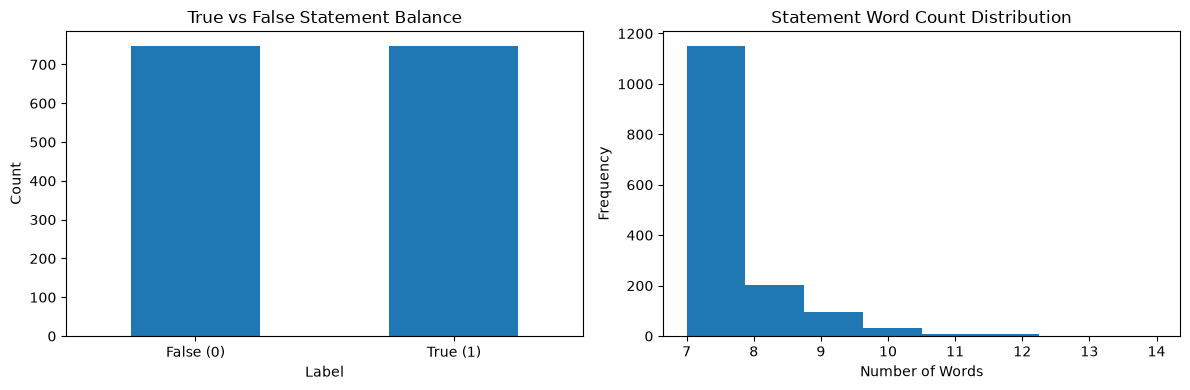

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance
cities["label"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("True vs False Statement Balance")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["False (0)", "True (1)"], rotation=0)

# Word count distribution
cities["word_count"].plot(
    kind="hist",
    bins=8,
    ax=axes[1]
)
axes[1].set_title("Statement Word Count Distribution")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

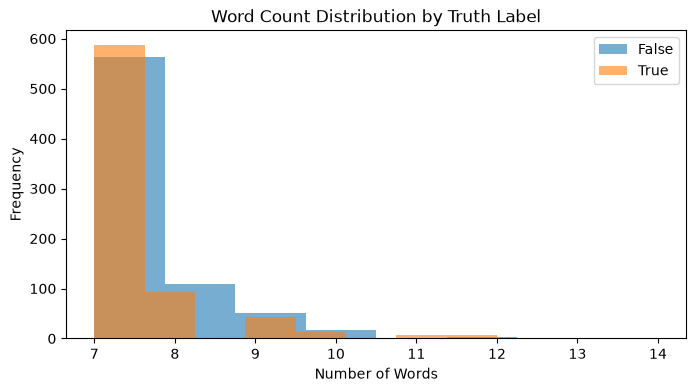

In [10]:
plt.figure(figsize=(8, 4))

cities[cities["label"] == 0]["word_count"].plot(
    kind="hist",
    bins=8,
    alpha=0.6,
    label="False"
)

cities[cities["label"] == 1]["word_count"].plot(
    kind="hist",
    bins=8,
    alpha=0.6,
    label="True"
)

plt.title("Word Count Distribution by Truth Label")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()